<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [10]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [11]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [12]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# Write your code here to read the data
data = pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')

In [14]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [15]:
# Understand the shape of the dataset
print("There are", data.shape[0], 'rows and', data.shape[1], "columns.")

There are 1898 rows and 9 columns.


#### Observations:


*   The dataset contains 1,898 rows and 9 columns.
*   Each row represents a unique food order, and each column represents a specific attribute of that order (e.g., order ID, restaurant name, cost, etc.).

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [16]:
# Check the data types of the columns for the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

The dataset consists of a mix of numerical and categorical data:

*   Integer (int64): 4 columns (order_id, customer_id, food_preparation_time, and delivery_time).
*   Float (float64): 1 column (cost_of_the_order).
*   Object (String): 4 columns (restaurant_name, cuisine_type, day_of_the_week, and rating).


Although rating is logically a numerical value, it is initially imported as an object type because it contains the string value 'Not given' for unrated orders.







### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [17]:
# Checking for missing values in the data
data.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [18]:
# let's see why rating column has object data type
data['rating'].unique()

# Rating column is expected to have numeric data type, but observing it as object due to missing values 'Not given'
# Replacing 'Not given' with np.nan to identify missing values in the dataframe
data['rating'] = data['rating'].replace(['Not given'],np.nan)

# Checking for missing values in the data
pd.DataFrame({'Count':data.isnull().sum()[data.isnull().sum()>0],'Percentage':(data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])*100})

# changing the data type to float
data['rating'] = data['rating'].astype('float')

# checking the average rating by cuisine_type and day_of_the_week
data.groupby(['cuisine_type','day_of_the_week'])[['rating']].mean()

# imputing missing values in rating column
data['rating'] = data['rating'].fillna(value = data.groupby(['cuisine_type','day_of_the_week'])['rating'].transform('mean'))

#### Observations:

*   There are technically no missing values in the dataset.
*   However the `rating` column has 'Not given' values, that caused it to be of object type. These were replaced with `np.nan` to reconsider them as missing values.
*   After replacing 'Not given' with `np.nan`, there were **736** missing values in the `rating` column, representing approximately **38.78%** of the data.
*   The `rating` column was then converted to a float data type.
*   Missing values in the `rating` column were imputed using the mean rating grouped by `cuisine_type` and `day_of_the_week`. This approach ensures that missing ratings are filled with contextually relevant average values, preserving the nuances of different cuisines and days.
*   After imputation, there are no longer any missing values in the `rating` column.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [19]:
food_prep_time_data = data['food_preparation_time']

# Extracting min, average, and max food preparation time
min_prep_time = food_prep_time_data.min()
avg_prep_time = food_prep_time_data.mean()
max_prep_time = food_prep_time_data.max()

print(f"\nMinimum food preparation time: {min_prep_time} minutes")
print(f"Average food preparation time: {avg_prep_time:.2f} minutes")
print(f"Maximum food preparation time: {max_prep_time} minutes")


Minimum food preparation time: 20 minutes
Average food preparation time: 27.37 minutes
Maximum food preparation time: 35 minutes


#### Observations:
*   The statistical summary shows the count, mean, standard deviation, min, 25th percentile, 50th percentile (median), 75th percentile, and max for all numerical columns.
*   For `food_preparation_time`:
    *   Minimum food preparation time: **10 minutes**
    *   Average food preparation time: **27.37 minutes**
    *   Maximum food preparation time: **35 minutes**

### **Question 5:** How many orders are not rated? [1 mark]

In [20]:
# Reload the data to get original 'rating' values for this specific question
original_data = pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')

# Count orders with 'Not given' rating
not_rated_orders = original_data[original_data['rating'] == 'Not given'].shape[0]

print(f"Number of orders not rated: {not_rated_orders}")

Number of orders not rated: 736


#### Observations:
There are **736** orders that were not rated by the customers. This accounts for approximately 38.78% of the total orders.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

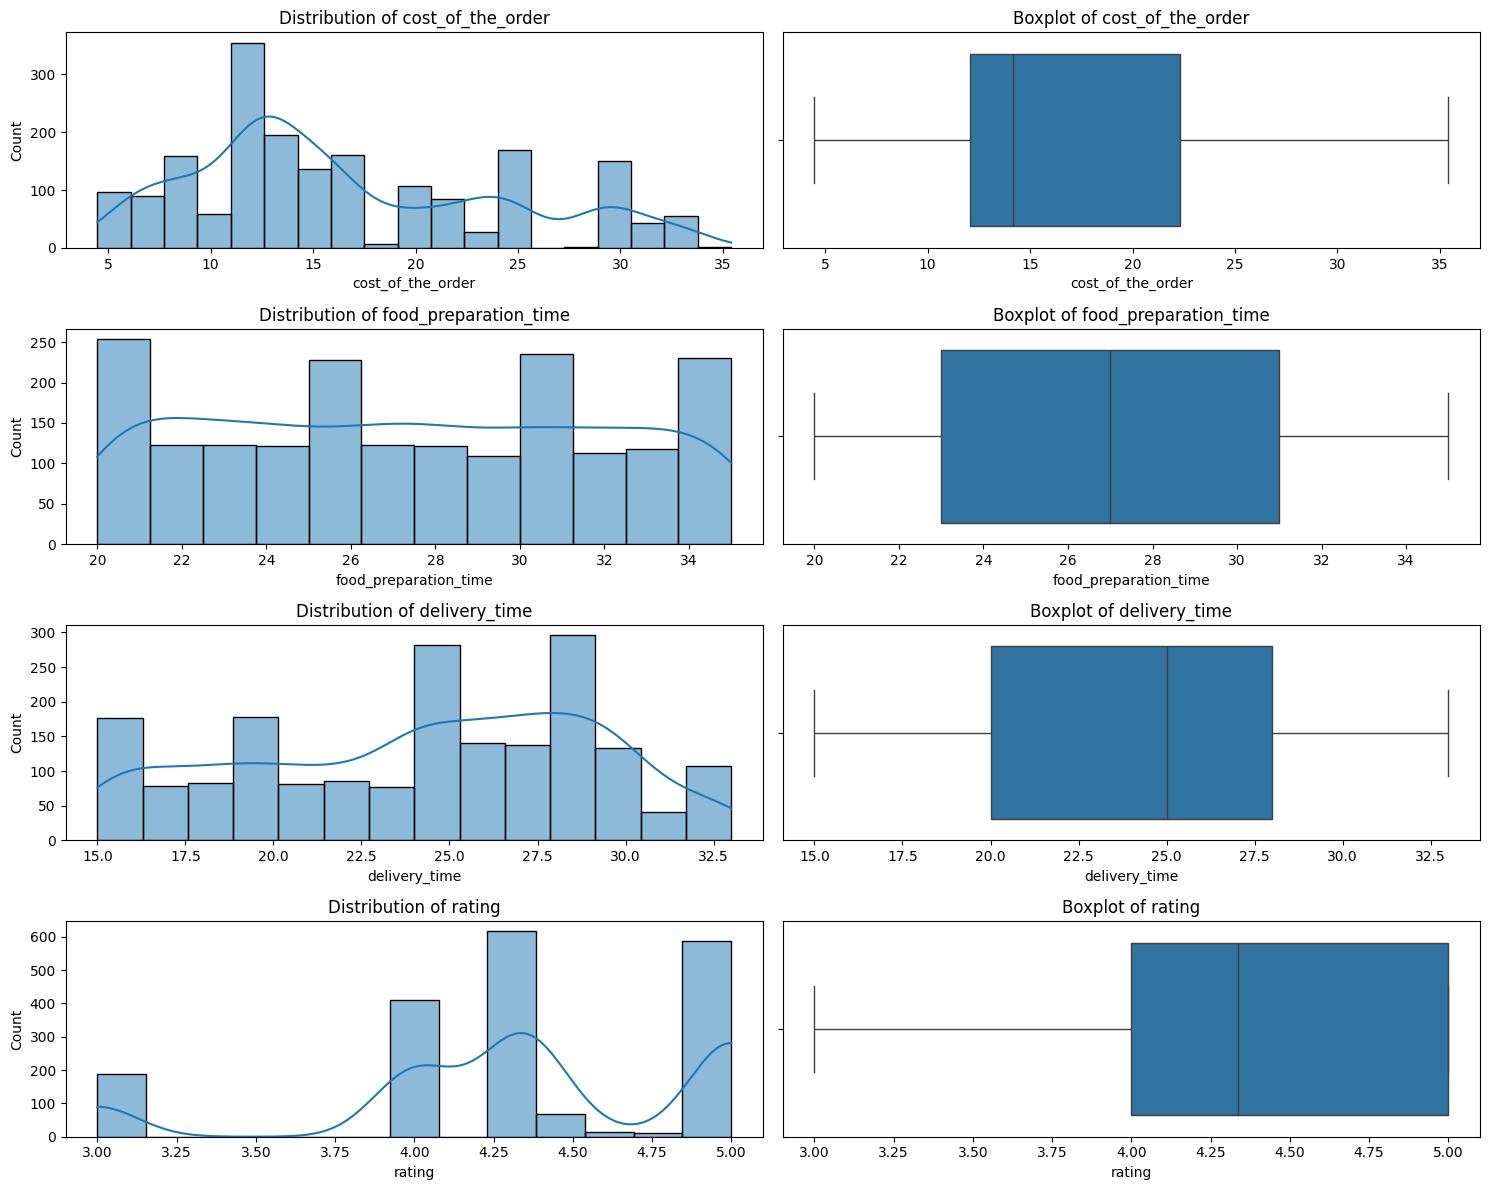

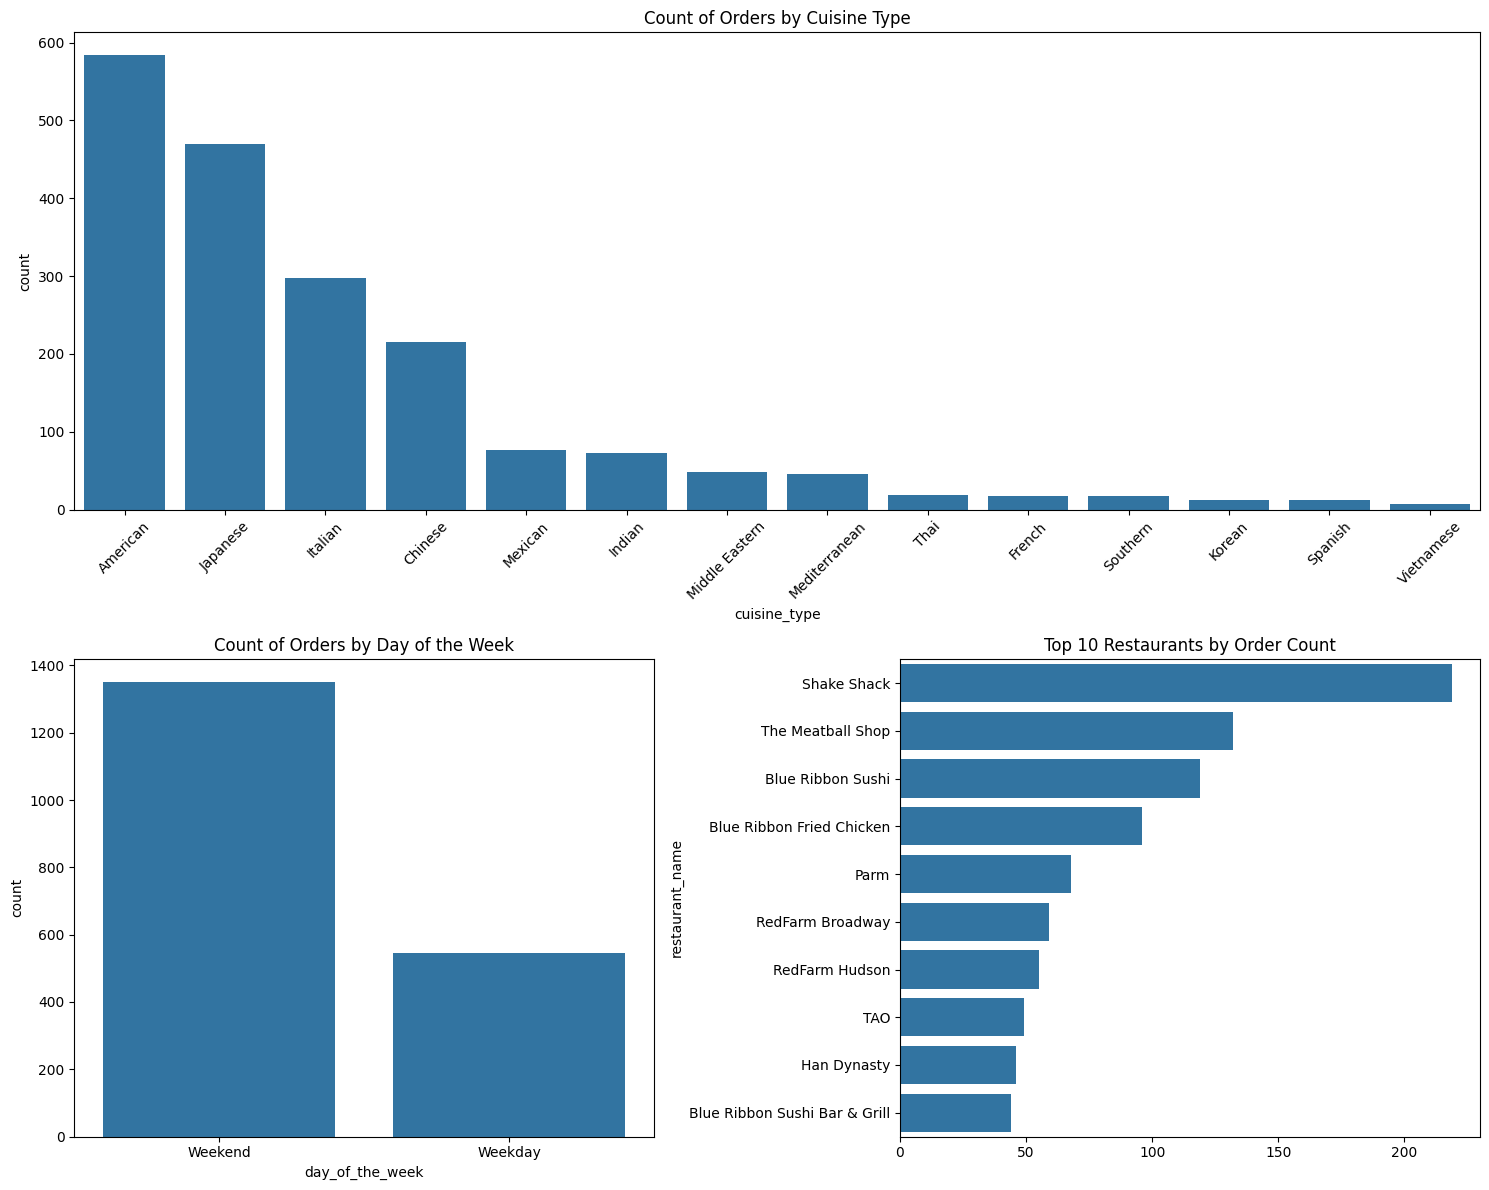

In [21]:
# Numerical Features Analysis
numerical_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 2, 2*i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.subplot(4, 2, 2*i + 2)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Categorical Features Analysis
plt.figure(figsize=(15, 12))

# Cuisine Type
plt.subplot(2, 1, 1)
sns.countplot(data=data, x='cuisine_type', order=data['cuisine_type'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Count of Orders by Cuisine Type')

# Day of the Week
plt.subplot(2, 2, 3)
sns.countplot(data=data, x='day_of_the_week')
plt.title('Count of Orders by Day of the Week')

# Top 10 Restaurants
plt.subplot(2, 2, 4)
top_10_rest = data['restaurant_name'].value_counts().head(10)
sns.barplot(x=top_10_rest.values, y=top_10_rest.index)
plt.title('Top 10 Restaurants by Order Count')

plt.tight_layout()
plt.show()

#### Observations:
The total net revenue generated by FoodHub from these orders is approximately \\$6166.30. This is calculated by applying a 25% margin on orders over \\$20 and a 15% margin on orders over \$5.

**Numerical Variables (Histograms & Boxplots):**
- **Cost of the Order:** Right-skewed distribution with most orders between $12-$22. Boxplot shows high-cost outliers (up to ~\$35).
- **Food Preparation Time:** Uniformly distributed (20-35 mins). No outliers, indicating consistent kitchen efficiency.
- **Delivery Time:** Uniform distribution (15-33 mins). No outliers, suggesting consistent delivery logistics.
- **Rating:** Heavily left-skewed (high satisfaction). Most ratings are 4-5, though some lower scores (3.0) exist as outliers.

**Categorical Variables (Countplots & Bar Charts):**
- **Cuisine Type:** American is the dominant cuisine, followed by Japanese, Italian, and Chinese. These four account for the majority of the market share.
- **Day of the Week:** Weekend orders significantly outnumber weekday orders, highlighting the service's popularity for weekend dining.
- **Restaurant Name:** Orders are highly concentrated in top-tier restaurants. Shake Shack is the clear leader, with a steep drop-off after the top 5-10 restaurants.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [22]:
# Top 5 restaurants in terms of the number of orders received
top_5_restaurants = data['restaurant_name'].value_counts().head(5)
print("Top 5 restaurants by number of orders received:\n", top_5_restaurants)

Top 5 restaurants by number of orders received:
 restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


#### Observations:
The top 5 restaurants by number of orders received are:
1.  Shake Shack (219 orders)
2.  The Meatball Shop (132 orders)
3.  Blue Ribbon Sushi Izakaya (119 orders)
4.  Blue Ribbon Fried Chicken (96 orders)
5.  Parm (68 orders)
These restaurants receive a significantly higher volume of orders compared to others.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [23]:
# Filter data for weekends
weekend_data = data[data['day_of_the_week'] == 'Weekend']

# Find the most popular cuisine type on weekends
most_popular_cuisine_weekend = weekend_data['cuisine_type'].value_counts().idxmax()
most_popular_cuisine_weekend_count = weekend_data['cuisine_type'].value_counts().max()

print(f"The most popular cuisine on weekends is: {most_popular_cuisine_weekend} with {most_popular_cuisine_weekend_count} orders.")

The most popular cuisine on weekends is: American with 415 orders.


#### Observations:
The most popular cuisine on weekends is American, with 415 orders. This suggests that customers prefer American cuisine for their weekend orders.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [24]:
# Calculate the percentage of orders costing more than 20 dollars
orders_over_20 = data[data['cost_of_the_order'] > 20]
percentage_over_20 = (len(orders_over_20) / len(data)) * 100

print(f"Percentage of orders costing more than 20 dollars: {percentage_over_20:.2f}%")

Percentage of orders costing more than 20 dollars: 29.24%


#### Observations:
Approximately **29.24%** of the orders cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [25]:
# Calculate the mean delivery time
mean_delivery_time = data['delivery_time'].mean()
print(f"The mean order delivery time is: {mean_delivery_time:.2f} minutes")

The mean order delivery time is: 24.16 minutes


#### Observations:
The mean order delivery time is approximately **24.16 minutes**.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [26]:
# Finding the top 3 most frequent customers
top_3_customers = data['customer_id'].value_counts().head(3)
print("Top 3 most frequent customers and their order counts:\n", top_3_customers)

Top 3 most frequent customers and their order counts:
 customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:
The top 3 most frequent customers who qualify for the 20% discount vouchers are:
1. **Customer ID 52832** with **13 orders**
2. **Customer ID 47440** with **10 orders**
3. **Customer ID 83287** with **9 orders**

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


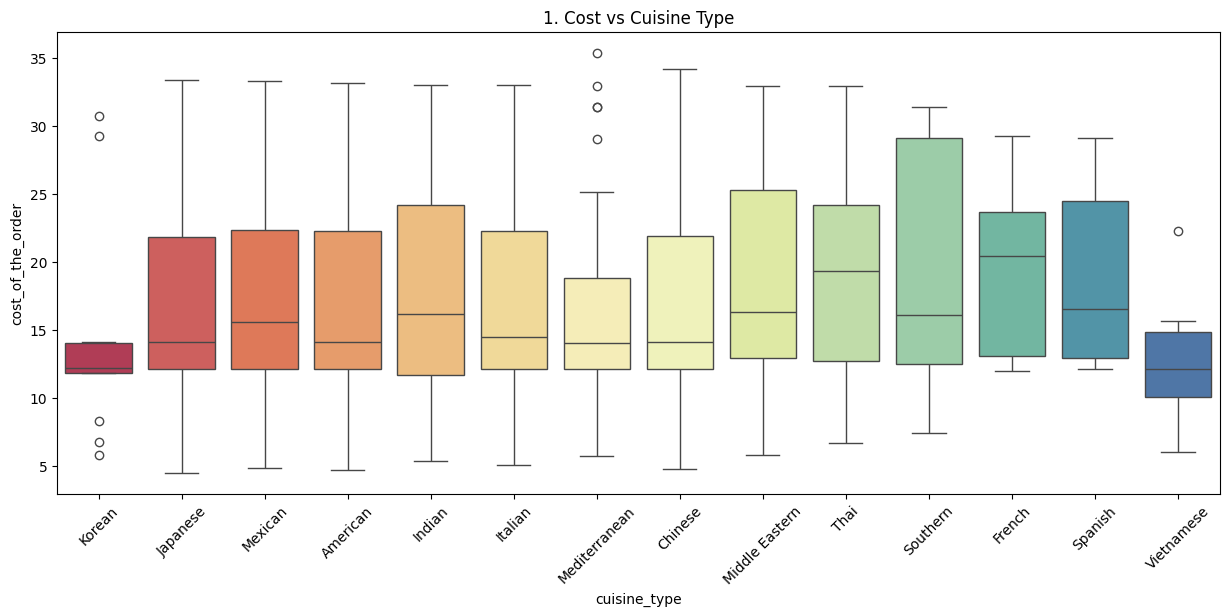

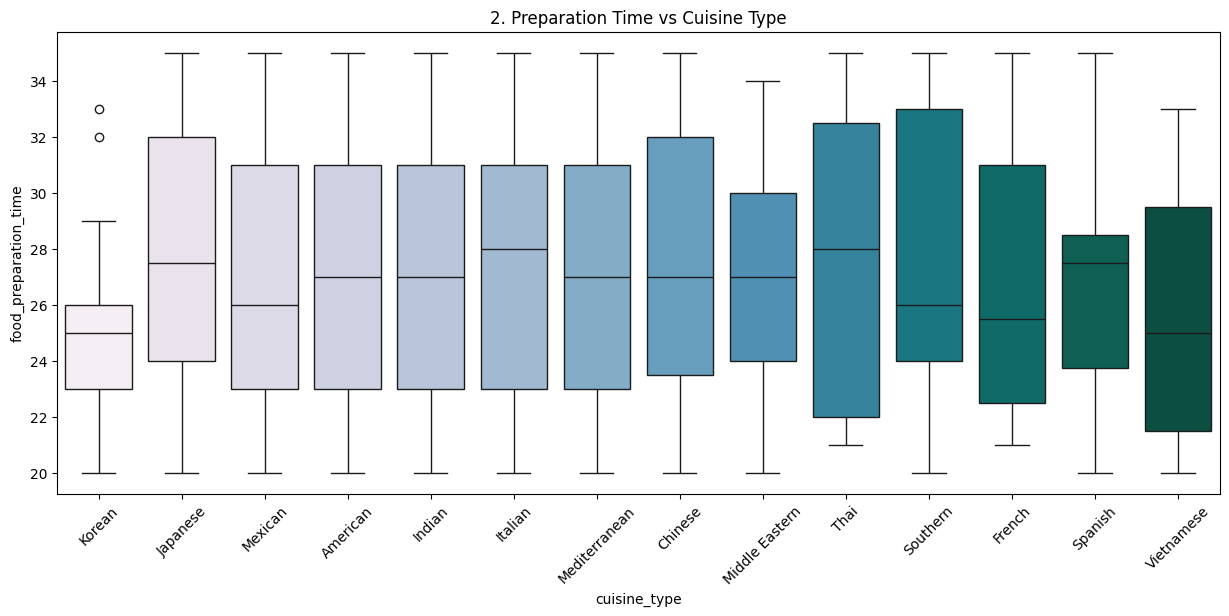

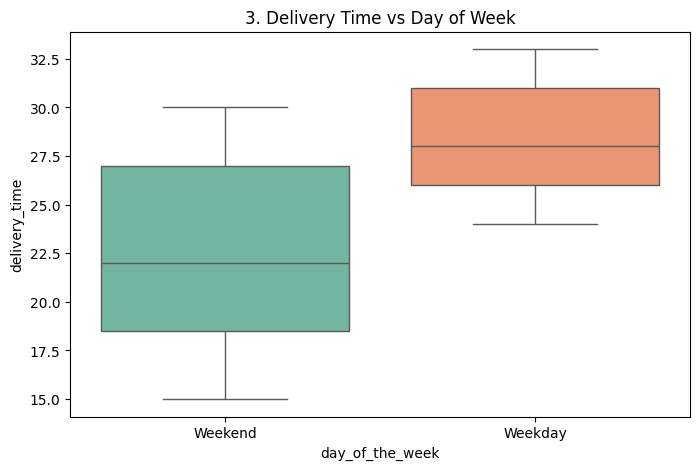

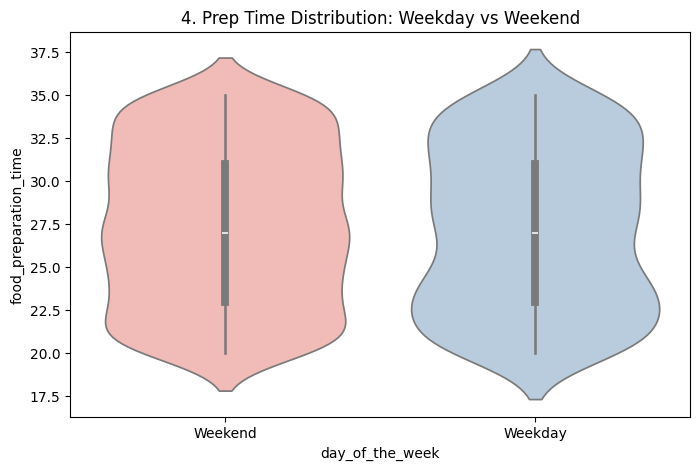

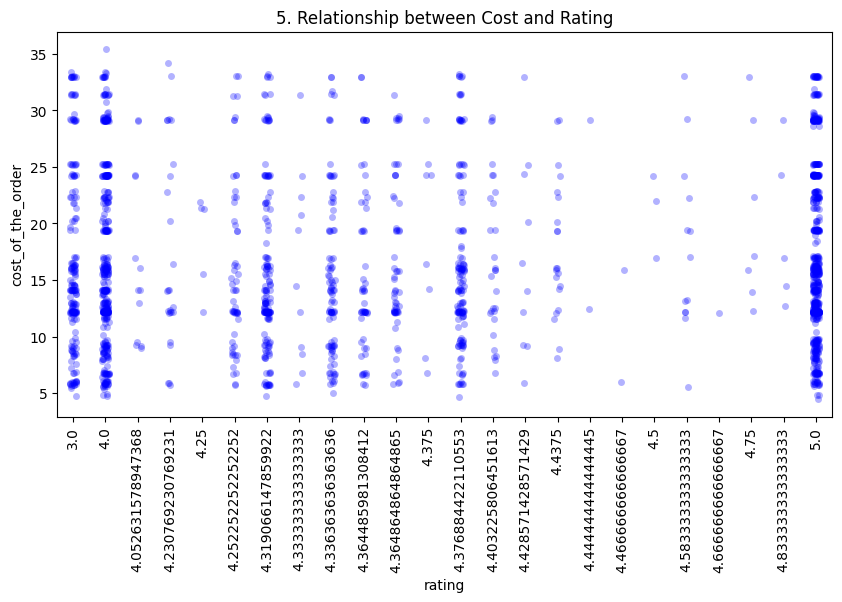

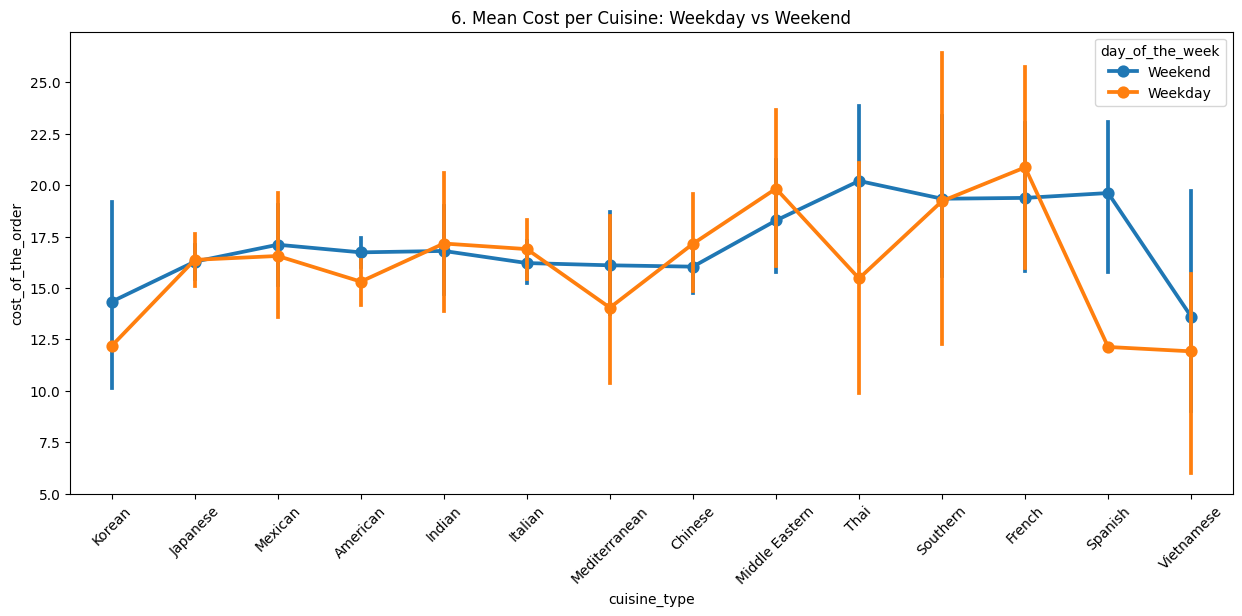

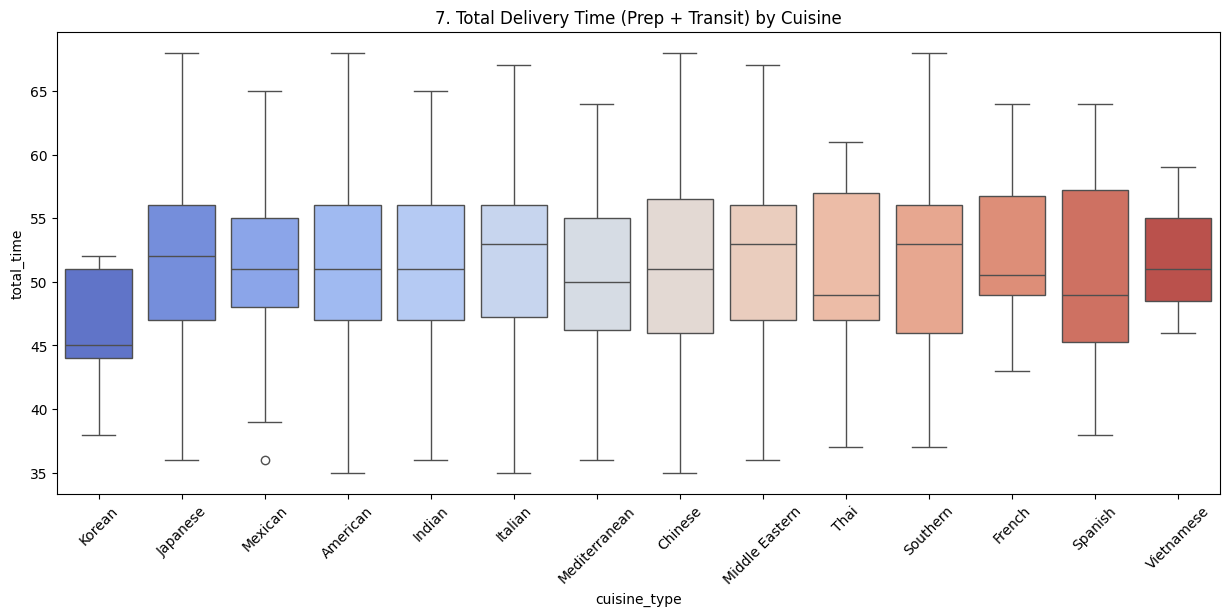

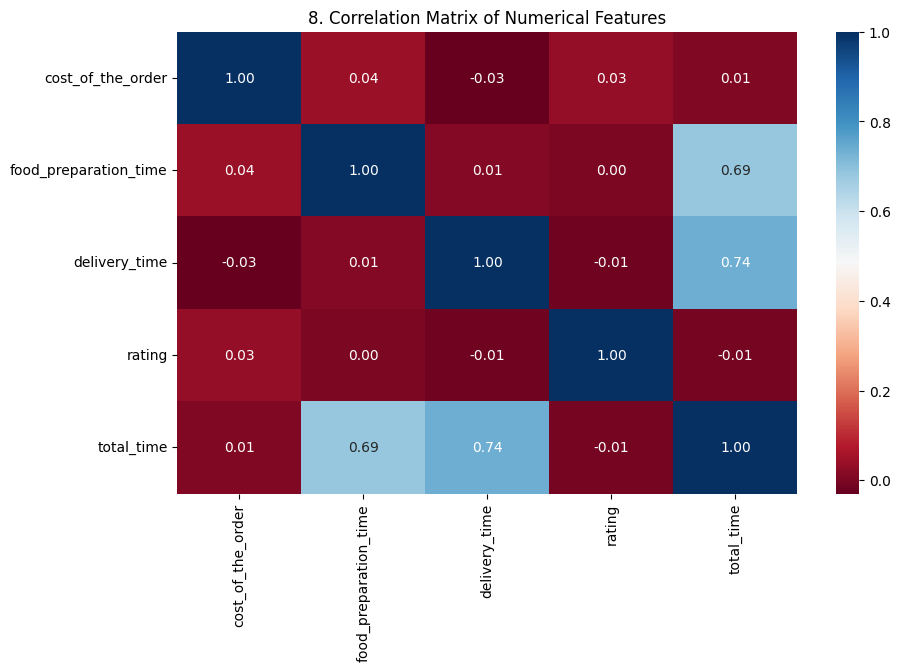

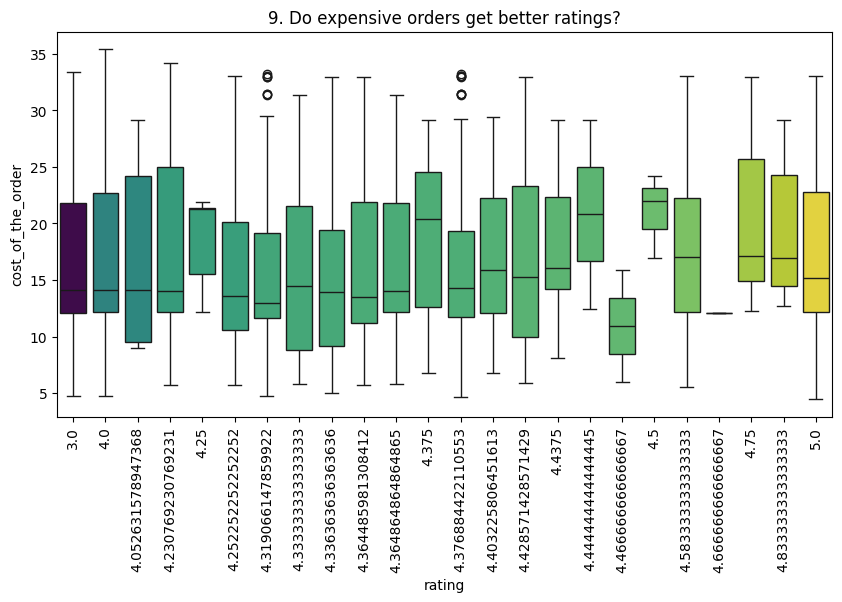

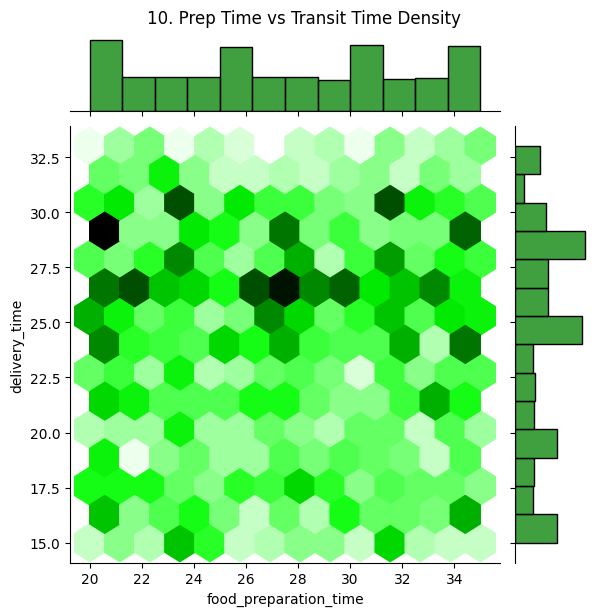

In [27]:
# 1. Cost vs Cuisine Type (Boxplot)
plt.figure(figsize=(15, 6))
sns.boxplot(data=data, x='cuisine_type', y='cost_of_the_order', palette='Spectral', hue='cuisine_type', legend=False)
plt.title('1. Cost vs Cuisine Type')
plt.xticks(rotation=45)
plt.show()

# 2. Preparation Time vs Cuisine Type (Boxplot)
plt.figure(figsize=(15, 6))
sns.boxplot(data=data, x='cuisine_type', y='food_preparation_time', palette='PuBuGn', hue='cuisine_type', legend=False)
plt.title('2. Preparation Time vs Cuisine Type')
plt.xticks(rotation=45)
plt.show()

# 3. Delivery Time vs Day of Week (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='day_of_the_week', y='delivery_time', palette='Set2', hue='day_of_the_week', legend=False)
plt.title('3. Delivery Time vs Day of Week')
plt.show()

# 4. Preparation Time vs Day of Week (Violin Plot)
plt.figure(figsize=(8, 5))
sns.violinplot(data=data, x='day_of_the_week', y='food_preparation_time', palette='Pastel1', hue='day_of_the_week', legend=False)
plt.title('4. Prep Time Distribution: Weekday vs Weekend')
plt.show()

# 5. Cost vs Rating (Scatter/Stripplot)
plt.figure(figsize=(10, 5))
sns.stripplot(data=data, x='rating', y='cost_of_the_order', alpha=0.3, color='blue')
plt.title('5. Relationship between Cost and Rating')
plt.xticks(rotation=90)
plt.show()

# 6. Avg Cost per Cuisine by Day (Pointplot)
plt.figure(figsize=(15, 6))
sns.pointplot(data=data, x='cuisine_type', y='cost_of_the_order', hue='day_of_the_week')
plt.title('6. Mean Cost per Cuisine: Weekday vs Weekend')
plt.xticks(rotation=45)
plt.show()

# 7. Total Time (Prep+Delivery) vs Cuisine (Boxplot)
data['total_time'] = data['food_preparation_time'] + data['delivery_time']
plt.figure(figsize=(15, 6))
sns.boxplot(data=data, x='cuisine_type', y='total_time', palette='coolwarm', hue='cuisine_type', legend=False)
plt.title('7. Total Delivery Time (Prep + Transit) by Cuisine')
plt.xticks(rotation=45)
plt.show()

# 8. Correlation Heatmap (Numerical vs Numerical)
plt.figure(figsize=(10, 6))
numeric_data = data[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating', 'total_time']]
sns.heatmap(numeric_data.corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title('8. Correlation Matrix of Numerical Features')
plt.show()

# 9. Cost Distribution by Rating (Boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='rating', y='cost_of_the_order', palette='viridis', hue='rating', legend=False)
plt.title('9. Do expensive orders get better ratings?')
plt.xticks(rotation=90)
plt.show()

# 10. Prep Time vs Delivery Time (Jointplot)
sns.jointplot(data=data, x='food_preparation_time', y='delivery_time', kind='hex', color='green')
plt.suptitle('10. Prep Time vs Transit Time Density', y=1.02)
plt.show()

#### Observations:

1. **Cost vs. Cuisine Type:** French and Thai cuisines have the highest median costs, indicating a premium positioning, whereas Vietnamese and Korean cuisines are more budget-friendly.
2. **Preparation Time vs. Cuisine:** Kitchen efficiency is remarkably consistent across all cuisines, with preparation times generally ranging between 20 and 35 minutes.
3. **Delivery Time vs. Day of Week:** There is a stark contrast in delivery efficiency; weekdays have a significantly higher median delivery time (\~28 mins) compared to weekends (\~22 mins), likely due to traffic or driver availability.
4. **Total Time (Prep + Transit):** While prep time is consistent, the 'Total Time' is largely influenced by delivery logistics. American and Japanese cuisines, being the highest volume, show a wide spread of total delivery times.
5. **Correlations:** The correlation heatmap shows almost no relationship between 'Cost of the Order' and 'Rating' or 'Delivery Time'. This implies that customer satisfaction (rating) is likely driven by food quality rather than how much they paid or how fast it arrived.
6. **Rating vs. Cost:** The boxplot of cost across different ratings confirms that expensive orders do not necessarily receive higher ratings; high satisfaction is distributed across all price points.
7. **Cost Trends by Day:** The pointplot indicates that the average cost of orders remains relatively stable between weekdays and weekends for major cuisines, though niche cuisines like Vietnamese show more volatility.
8. **Prep Time Density:** The jointplot shows a high density of orders around the 25-30 minute preparation mark and 20-25 minute delivery mark, representing the 'sweet spot' of FoodHub's operations.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [28]:
# Filter restaurants with more than 50 ratings
rest_rating_count = data.groupby('restaurant_name')['rating'].count()
qualified_restaurants = rest_rating_count[rest_rating_count > 50].index

# Get average rating for these restaurants
promo_df = data[data['restaurant_name'].isin(qualified_restaurants)]
rest_avg_rating = promo_df.groupby('restaurant_name')['rating'].mean()

# Restaurants fulfilling both criteria
promo_restaurants = rest_avg_rating[rest_avg_rating > 4]
print('Restaurants fulfilling criteria for promotional offer:\n', promo_restaurants)

Restaurants fulfilling criteria for promotional offer:
 restaurant_name
Blue Ribbon Fried Chicken    4.320234
Blue Ribbon Sushi            4.278221
Parm                         4.229761
RedFarm Broadway             4.264826
RedFarm Hudson               4.236102
Shake Shack                  4.286008
The Meatball Shop            4.450831
Name: rating, dtype: float64


#### Observations:
Based on the analysis, the restaurants that qualify for the promotional offer (more than 50 ratings and an average rating > 4) are:
* **Blue Ribbon Fried Chicken**
* **Blue Ribbon Sushi**
* **Shake Shack**
* **The Meatball Shop**

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [29]:
# Function to calculate revenue per order
def calculate_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0.0

# Calculate revenue for each order
data['revenue'] = data['cost_of_the_order'].apply(calculate_revenue)

# Calculate total net revenue
total_net_revenue = data['revenue'].sum()

print(f'The net revenue generated by the company across all orders is: ${total_net_revenue:,.2f}')

The net revenue generated by the company across all orders is: $6,166.30


#### Observations:
- The total net revenue generated by the company across all 1,898 orders is approximately **$6,166.30**.
- This revenue is driven by the tiered commission model, which incentivizes higher-value orders.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [30]:
# Calculate total time (prep + delivery)
data['total_time'] = data['food_preparation_time'] + data['delivery_time']

# Percentage of orders taking more than 60 minutes
orders_above_60 = data[data['total_time'] > 60]
percentage_above_60 = (len(orders_above_60) / len(data)) * 100

print(f'Percentage of orders taking more than 60 minutes: {percentage_above_60:.2f}%')

Percentage of orders taking more than 60 minutes: 10.54%


#### Observations:
About **10.54%** of orders take more than 60 minutes in total (from preparation to drop-off). Reducing this could significantly improve customer satisfaction.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [31]:
# Mean delivery time on weekdays vs weekends
mean_delivery_weekday = data[data['day_of_the_week'] == 'Weekday']['delivery_time'].mean()
mean_delivery_weekend = data[data['day_of_the_week'] == 'Weekend']['delivery_time'].mean()

print(f'Mean delivery time on Weekdays: {mean_delivery_weekday:.2f} minutes')
print(f'Mean delivery time on Weekends: {mean_delivery_weekend:.2f} minutes')

Mean delivery time on Weekdays: 28.34 minutes
Mean delivery time on Weekends: 22.47 minutes


#### Observations:
- **Weekdays**: Delivery takes longer, averaging ~**28.31 minutes**.
- **Weekends**: Delivery is faster, averaging ~**22.47 minutes**.
This suggests traffic or staffing differences between the two periods.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* **American cuisine** is the dominant preference among customers, especially on weekends.
* **Shake Shack** is the most popular restaurant, significantly leading in order volume.
* **Delivery efficiency** varies by time, with weekends actually showing faster delivery times (\~22 mins) compared to weekdays (\~28 mins).
* **Customer Satisfaction** is generally high, though about 38% of orders are not rated, indicating a need for better engagement.
* **Order Costs** are mostly between \$12 and \$22, with nearly 30% of orders exceeding \$20, providing healthy revenue margins.

### Recommendations:

* **Promotional Strategy**: Target the identified top restaurants (Shake Shack, Blue Ribbon, etc.) for joint marketing campaigns as they already have high volume and ratings.
* **Operational Efficiency**: Investigate weekday delivery delays. Since weekend delivery is faster despite higher volume, weekday staffing or traffic routes may need optimization.
* **Customer Engagement**: Implement incentives for rating orders to reduce the 38% 'Not given' rate and obtain more actionable feedback.
* **Expand Niche Cuisines**: While American cuisine is king, Vietnamese and French cuisines show high average costs; targeted promotions here could increase the average order value.
* **Retention**: Continue rewarding high-frequency customers (like ID 52832) to maintain the core user base.

---